# Data Analytics Project 2: Exploratory Data Analysis (EDA)

## Introduction

This project focuses on Exploratory Data Analysis (EDA) of an e-commerce dataset. The analysis is used to understand patterns, trends, distributions, basic statistics, and outliers in the data.

In [5]:
import pandas as pd

In [9]:
!pip install openpyxl

## 1. Dataset Loading and Overview

The dataset was loaded into Python using the Pandas library. It contains e-commerce order information, including order details, customer information, products, prices, payment methods, order status, and referral sources.

In [11]:
df = pd.read_excel("Dataset for Data Analytics (1).xlsx")

In [12]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [13]:
df.shape

(1200, 14)

## Dataset Dimensions:

The dataset contains 1,200 rows and 14 columns.

In [14]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

## 2. Data Quality and Cleaning

Before performing the analysis, the dataset was checked for data types, missing values, and duplicate records.

In [15]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [16]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

### Missing Values

The dataset contains 309 missing values in the CouponCode column. All other columns contain no missing values.

In [17]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records

No duplicate rows were found in the dataset. Therefore, no duplicate records needed to be removed.

## 3. Basic Statistical Analysis

Basic descriptive statistics were calculated to understand the numerical variables in the dataset. The analysis includes the count, mean, median, minimum, and maximum values.

In [18]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### Mean and Median Observations

The average quantity per order is approximately 2.95 units, while the median is 3 units.

The average unit price is approximately 356.41, with a median of 364.21.

The average number of items in the cart is approximately 5.49, with a median of 5.

The average total price per order is approximately 1,053.97, while the median is approximately 823.62. The higher mean compared with the median indicates that some orders have relatively high total prices.

In [19]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].agg(['count', 'mean', 'median'])


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.00000,1200.000,1200.0000
mean,2.945833,356.41275,5.485,1053.9683
median,3.000000,364.21000,5.000,823.6150


In [21]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].boxplot()

<Axes: >

## 4. Outlier Analysis

Boxplots were used to identify possible outliers in the numerical variables Quantity, UnitPrice, ItemsInCart, and TotalPrice.

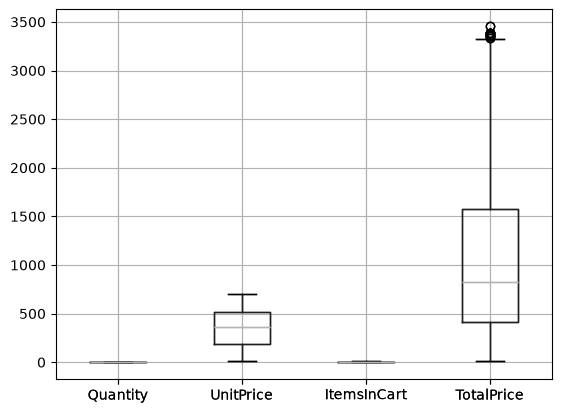

In [22]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].boxplot()
import matplotlib.pyplot as plt
plt.show()

### Outlier Observation

The boxplot shows several possible outliers in the TotalPrice column. These represent orders with unusually high total prices compared with the majority of orders. The outliers were retained because they may represent legitimate high-value purchases.

## 5. Trend Analysis

To identify sales trends over time, the total sales were aggregated by month and visualized using a line chart.

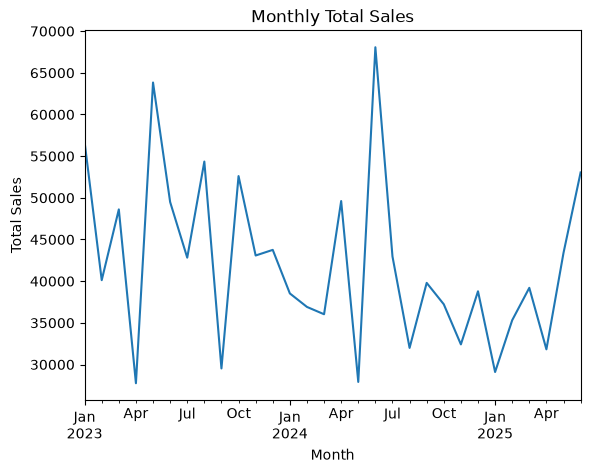

In [23]:
df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum().plot()
plt.title('Monthly Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

### Trend Observation

Monthly total sales fluctuate throughout the period from January 2023 to June 2025. Some months have relatively high sales, while other months have lower sales. Overall, the chart does not show a consistent upward or downward trend.

In [25]:
df['Date'].min(), df['Date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-06-30 00:00:00'))

In [28]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [29]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [30]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [31]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [33]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

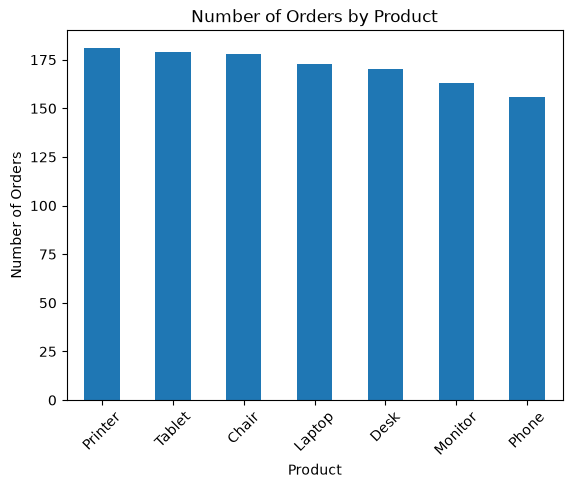

In [34]:
df['Product'].value_counts().plot(kind='bar')

plt.title('Number of Orders by Product')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [35]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [36]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [37]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [38]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [39]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [40]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


## 7. Key Observations

The main observations from the exploratory data analysis are:

- The dataset contains 1,200 orders and 14 columns.
- There are 309 missing values in the CouponCode column.
- No duplicate records were found.
- The average quantity per order is approximately 2.95 units.
- The average unit price is approximately 356.41.
- The average total price per order is approximately 1,053.97.
- Some unusually high TotalPrice values were identified as possible outliers.
- Monthly sales fluctuate over time without a consistent upward or downward trend.
- UnitPrice has the strongest positive correlation with TotalPrice among the numerical variables analyzed.

## 8. Conclusion

The exploratory data analysis provided an overview of the e-commerce dataset and revealed several useful patterns.

The dataset contains 1,200 orders with information about products, quantities, prices, payment methods, order statuses, and referral sources. The analysis showed that the average total price per order is approximately 1,053.97.

Some high-value orders were identified as possible outliers in the TotalPrice column. Monthly sales also showed fluctuations over time rather than a consistent upward or downward trend.

The correlation analysis showed a positive relationship between UnitPrice and TotalPrice, as well as between Quantity and TotalPrice.

Overall, the EDA helped identify important patterns, distributions, trends, and unusual values in the dataset.